# The Complete Pandas Notebook
### Every major function — syntax, working examples, common errors, and fixes

This notebook is organized into 20 sections mirroring real data-analysis workflow:
load data → inspect → select → clean → transform → aggregate → group → merge →
dates → text → categories → reshape → compare → correlate → rolling stats →
plot → optimize → iterate → misc utilities.

**How each function is documented:**
1. **Purpose** — what real-world problem it solves
2. **Syntax** — working code + real output
3. **Common Error** — a mistake beginners make, the actual error message, and the fix

Run cells top to bottom — later cells depend on the `df` sample dataset created in Section 0.


## 0. Setup — Sample Dataset
We'll use one consistent dataset throughout so every example is comparable.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

df = pd.DataFrame({
    'employee_id': [101, 102, 103, 104, 105, 106, 107, 108],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Evan', 'Fiona', 'George', 'Hana'],
    'department': ['Sales', 'IT', 'Sales', 'HR', 'IT', 'Sales', 'HR', 'IT'],
    'salary': [55000, 72000, 58000, 61000, 75000, np.nan, 62000, 80000],
    'age': [25, 34, 29, 41, 38, 30, 45, 27],
    'join_date': pd.to_datetime(['2019-03-01','2018-07-15','2020-01-10','2017-11-23',
                                  '2021-05-02','2019-09-19','2016-02-14','2022-01-30']),
    'bonus_pct': [0.05, 0.10, 0.07, 0.06, 0.12, 0.04, np.nan, 0.15]
})
df

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07
3,104,Diana,HR,61000.0,41,2017-11-23,0.06
4,105,Evan,IT,75000.0,38,2021-05-02,0.12
5,106,Fiona,Sales,NaN,30,2019-09-19,0.04
6,107,George,HR,62000.0,45,2016-02-14,NaN
7,108,Hana,IT,80000.0,27,2022-01-30,0.15


A second small DataFrame to demonstrate merging/joining/concatenation later.

In [2]:
dept_info = pd.DataFrame({
    'department': ['Sales', 'IT', 'HR', 'Marketing'],
    'manager': ['Rita', 'Sam', 'Nora', 'Leo'],
    'budget': [500000, 900000, 300000, 250000]
})
dept_info

,department,manager,budget
0,Sales,Rita,500000
1,IT,Sam,900000
2,HR,Nora,300000
3,Marketing,Leo,250000


## 1. Reading & Writing Data (I/O)

### `pd.read_csv()`
**Purpose:** Load a CSV file into a DataFrame.

In [3]:
df.to_csv('/tmp/employees.csv', index=False)   # write first so we have a file to read
loaded = pd.read_csv('/tmp/employees.csv')
loaded.head(3)

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07


**Common Error with `pd.read_csv()`**

Reading a path that doesn't exist raises `FileNotFoundError`.

In [4]:
try:
    pd.read_csv('/tmp/does_not_exist.csv')
except Exception as e:
    print(f"{type(e).__name__}: {e}")

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/does_not_exist.csv'


**Fix:**

In [5]:
import os
path = '/tmp/does_not_exist.csv'
if os.path.exists(path):
    df_check = pd.read_csv(path)
else:
    print(f"File not found: {path} -> check the path/spelling or use an absolute path")

File not found: /tmp/does_not_exist.csv -> check the path/spelling or use an absolute path


### `pd.read_excel()`
**Purpose:** Load an Excel sheet into a DataFrame (requires `openpyxl`).

In [6]:
df.to_excel('/tmp/employees.xlsx', index=False)
loaded_xl = pd.read_excel('/tmp/employees.xlsx')
loaded_xl.head(3)

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07


**Common Error with `pd.read_excel()`**

Requesting a sheet name that isn't in the workbook raises a `ValueError`.

In [7]:
try:
    pd.read_excel('/tmp/employees.xlsx', sheet_name='DoesNotExist')
except Exception as e:
    print(f"{type(e).__name__}: {e}")

ValueError: Worksheet named 'DoesNotExist' not found


**Fix:**

In [8]:
xl = pd.ExcelFile('/tmp/employees.xlsx')
print("Available sheets:", xl.sheet_names)
loaded_xl = pd.read_excel('/tmp/employees.xlsx', sheet_name=xl.sheet_names[0])

Available sheets: ['Sheet1']


### `pd.read_json()`
**Purpose:** Load JSON data into a DataFrame.

In [9]:
df.to_json('/tmp/employees.json', orient='records')
loaded_json = pd.read_json('/tmp/employees.json')
loaded_json.head(3)

/tmp/ipykernel_608/3843376235.py:1: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df.to_json('/tmp/employees.json', orient='records')


,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,1551398400000,0.05
1,102,Bob,IT,72000.0,34,1531612800000,0.10
2,103,Charlie,Sales,58000.0,29,1578614400000,0.07


### `df.to_csv()`
**Purpose:** Export a DataFrame to a CSV file.

In [10]:
df.to_csv('/tmp/out.csv', index=False)
print("saved")

saved


### `df.to_dict()`
**Purpose:** Convert a DataFrame to a Python dictionary — useful for APIs/JSON payloads.

In [11]:
df.head(2).to_dict(orient='records')

[{'employee_id': 101,
  'name': 'Alice',
  'department': 'Sales',
  'salary': 55000.0,
  'age': 25,
  'join_date': Timestamp('2019-03-01 00:00:00'),
  'bonus_pct': 0.05},
 {'employee_id': 102,
  'name': 'Bob',
  'department': 'IT',
  'salary': 72000.0,
  'age': 34,
  'join_date': Timestamp('2018-07-15 00:00:00'),
  'bonus_pct': 0.1}]

### `df.to_numpy()`
**Purpose:** Convert a DataFrame to a raw NumPy array (drops labels) — useful for feeding ML models.

In [12]:
df[['age','salary']].to_numpy()[:3]

array([[2.5e+01, 5.5e+04],
       [3.4e+01, 7.2e+04],
       [2.9e+01, 5.8e+04]])

## 2. Inspecting Data

### `df.head()`
**Purpose:** Preview the first N rows to sanity-check the data.

In [13]:
df.head(3)

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07


### `df.tail()`
**Purpose:** Preview the last N rows.

In [14]:
df.tail(2)

,employee_id,name,department,salary,age,join_date,bonus_pct
6,107,George,HR,62000.0,45,2016-02-14,NaN
7,108,Hana,IT,80000.0,27,2022-01-30,0.15


### `df.sample()`
**Purpose:** Pull a random sample of rows — check for hidden patterns/bias.

In [15]:
df.sample(3, random_state=42)

,employee_id,name,department,salary,age,join_date,bonus_pct
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
5,106,Fiona,Sales,NaN,30,2019-09-19,0.04
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05


### `df.info()`
**Purpose:** See dtypes, non-null counts, and memory usage in one call.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   employee_id  8 non-null      int64         
 1   name         8 non-null      str           
 2   department   8 non-null      str           
 3   salary       7 non-null      float64       
 4   age          8 non-null      int64         
 5   join_date    8 non-null      datetime64[us]
 6   bonus_pct    7 non-null      float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 580.0 bytes


### `df.describe()`
**Purpose:** Get summary statistics (mean, std, quartiles) for numeric columns.

In [17]:
df.describe()

,employee_id,salary,age,join_date,bonus_pct
count,8.00000,7.000000,8.000000,8,7.000000
mean,104.50000,66142.857143,33.625000,2019-05-11 15:00:00,0.084286
min,101.00000,55000.000000,25.000000,2016-02-14 00:00:00,0.040000
25%,102.75000,59500.000000,28.500000,2018-05-17 12:00:00,0.055000
50%,104.50000,62000.000000,32.000000,2019-06-10 00:00:00,0.070000
75%,106.25000,73500.000000,38.750000,2020-05-08 12:00:00,0.110000
max,108.00000,80000.000000,45.000000,2022-01-30 00:00:00,0.150000
std,2.44949,9476.788687,7.130167,NaN,0.040356


### `df.shape`
**Purpose:** Get the (rows, columns) dimensions.

In [18]:
print(df.shape)

(8, 7)


### `df.columns`
**Purpose:** List all column names.

In [19]:
print(list(df.columns))

['employee_id', 'name', 'department', 'salary', 'age', 'join_date', 'bonus_pct']


### `df.dtypes`
**Purpose:** Check the data type of every column.

In [20]:
df.dtypes

employee_id             int64
name                      str
department                str
salary                float64
age                     int64
join_date      datetime64[us]
bonus_pct             float64
dtype: object

### `df.nunique()`
**Purpose:** Count unique values per column — tells you which columns are categorical.

In [21]:
df.nunique()

employee_id    8
name           8
department     3
salary         7
age            8
join_date      8
bonus_pct      7
dtype: int64

### `df.value_counts()`
**Purpose:** Frequency count of unique values in a column — find the most common category.

In [22]:
df['department'].value_counts()

department
Sales    3
IT       3
HR       2
Name: count, dtype: int64

### `df.memory_usage()`
**Purpose:** See how much memory each column consumes — useful for optimizing big data.

In [23]:
df.memory_usage(deep=True)

Index          132
employee_id     64
name           431
department     417
salary          64
age             64
join_date       64
bonus_pct       64
dtype: int64

## 3. Selecting & Indexing

### `df.loc[]`
**Purpose:** Select rows/columns by **label**.

In [24]:
df.loc[df['department'] == 'IT', ['name', 'salary']]

,name,salary
1,Bob,72000.0
4,Evan,75000.0
7,Hana,80000.0


**Common Error with `df.loc[]`**

Referencing a column name that doesn't exist raises `KeyError`.

In [25]:
try:
    df.loc[:, 'salaryyy']
except Exception as e:
    print(f"{type(e).__name__}: {e}")

KeyError: 'salaryyy'


**Fix:**

In [26]:
col = 'salaryyy'
if col in df.columns:
    result = df.loc[:, col]
else:
    print(f"'{col}' not found. Closest columns: {[c for c in df.columns if 'sal' in c.lower()]}")

'salaryyy' not found. Closest columns: ['salary']


### `df.iloc[]`
**Purpose:** Select rows/columns by **integer position**.

In [27]:
df.iloc[0:3, 0:3]

,employee_id,name,department
0,101,Alice,Sales
1,102,Bob,IT
2,103,Charlie,Sales


**Common Error with `df.iloc[]`**

Requesting a column index beyond the number of columns raises `IndexError`.

In [28]:
try:
    df.iloc[:, 20]
except Exception as e:
    print(f"{type(e).__name__}: {e}")

IndexError: single positional indexer is out-of-bounds


**Fix:**

In [29]:
col_idx = 20
if col_idx < df.shape[1]:
    result = df.iloc[:, col_idx]
else:
    print(f"DataFrame only has {df.shape[1]} columns (valid indices 0-{df.shape[1]-1})")

DataFrame only has 7 columns (valid indices 0-6)

### `df.query()`
**Purpose:** Filter rows using a readable string expression instead of boolean masks.

In [30]:
df.query('salary > 60000 and department == "IT"')

,employee_id,name,department,salary,age,join_date,bonus_pct
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
4,105,Evan,IT,75000.0,38,2021-05-02,0.12
7,108,Hana,IT,80000.0,27,2022-01-30,0.15


**Common Error with `df.query()`**

A malformed expression string raises a `SyntaxError` / `UndefinedVariableError` at parse time.

In [31]:
try:
    df.query('salary > 60000 and department == "IT" and')
except Exception as e:
    print(f"{type(e).__name__}: {e}")

SyntaxError: Python keyword not valid identifier in numexpr query (<unknown>, line 1)


**Fix:**

In [32]:
expr = 'salary > 60000 and department == "IT"'  # fixed: removed trailing 'and'
result = df.query(expr)

### `df.isin()`
**Purpose:** Check whether values are in a given list — quick multi-value filter.

In [33]:
df[df['department'].isin(['Sales', 'HR'])]

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07
3,104,Diana,HR,61000.0,41,2017-11-23,0.06
5,106,Fiona,Sales,NaN,30,2019-09-19,0.04
6,107,George,HR,62000.0,45,2016-02-14,NaN


### `df.where()`
**Purpose:** Keep values that meet a condition, replace the rest with NaN (keeps shape).

In [34]:
df['salary'].where(df['salary'] > 60000)

0        NaN
1    72000.0
2        NaN
3    61000.0
4    75000.0
5        NaN
6    62000.0
7    80000.0
Name: salary, dtype: float64

### `df.filter()`
**Purpose:** Select columns/rows by name pattern instead of a boolean mask.

In [35]:
df.filter(like='date')

,join_date
0,2019-03-01
1,2018-07-15
2,2020-01-10
3,2017-11-23
4,2021-05-02
5,2019-09-19
6,2016-02-14
7,2022-01-30


### `df.select_dtypes()`
**Purpose:** Select only columns of a certain dtype (e.g. numeric-only for correlation).

In [36]:
df.select_dtypes(include='number').head(3)

,employee_id,salary,age,bonus_pct
0,101,55000.0,25,0.05
1,102,72000.0,34,0.10
2,103,58000.0,29,0.07


## 4. Handling Missing Data

### `df.isna()`
**Purpose:** Detect missing values as a boolean mask.

In [37]:
df.isna().sum()

employee_id    0
name           0
department     0
salary         1
age            0
join_date      0
bonus_pct      1
dtype: int64

### `df.notna()`
**Purpose:** Detect non-missing values.

In [38]:
df['salary'].notna().sum()

np.int64(7)

### `df.dropna()`
**Purpose:** Remove rows (or columns) containing missing values.

In [39]:
df.dropna(subset=['salary'])

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07
3,104,Diana,HR,61000.0,41,2017-11-23,0.06
4,105,Evan,IT,75000.0,38,2021-05-02,0.12
6,107,George,HR,62000.0,45,2016-02-14,NaN
7,108,Hana,IT,80000.0,27,2022-01-30,0.15


### `df.fillna()`
**Purpose:** Fill missing values with a constant, the mean, or another method.

In [40]:
df_filled = df.copy()
df_filled['salary'] = df_filled['salary'].fillna(df_filled['salary'].mean())
df_filled['bonus_pct'] = df_filled['bonus_pct'].fillna(0)
df_filled[['name','salary','bonus_pct']]

,name,salary,bonus_pct
0,Alice,55000.000000,0.05
1,Bob,72000.000000,0.10
2,Charlie,58000.000000,0.07
3,Diana,61000.000000,0.06
4,Evan,75000.000000,0.12
5,Fiona,66142.857143,0.04
6,George,62000.000000,0.00
7,Hana,80000.000000,0.15


### `df.interpolate()`
**Purpose:** Fill missing values by interpolating between known values (good for time series/trends).

In [41]:
df['salary'].interpolate()

0    55000.0
1    72000.0
2    58000.0
3    61000.0
4    75000.0
5    68500.0
6    62000.0
7    80000.0
Name: salary, dtype: float64

### `df.ffill() / df.bfill()`
**Purpose:** Carry the last (or next) valid value forward/backward to fill gaps.

In [42]:
print(df['salary'].ffill().tolist())
print(df['salary'].bfill().tolist())

[55000.0, 72000.0, 58000.0, 61000.0, 75000.0, 75000.0, 62000.0, 80000.0]
[55000.0, 72000.0, 58000.0, 61000.0, 75000.0, 62000.0, 62000.0, 80000.0]


**Common Error with `df.ffill() / df.bfill()`**

Typo in the fillna 'method' argument raises `ValueError: Invalid fill method`.

In [43]:
try:
    df['salary'].fillna(method='ffilll')
except Exception as e:
    print(f"{type(e).__name__}: {e}")

TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'


**Fix:**

In [44]:
result = df['salary'].ffill()   # use the direct method instead of the deprecated 'method=' string

### `df.replace()`
**Purpose:** Replace specific values (e.g. placeholder codes) with something meaningful, like NaN.

In [45]:
df['department'].replace({'HR': 'Human Resources'})

0              Sales
1                 IT
2              Sales
3    Human Resources
4                 IT
5              Sales
6    Human Resources
7                 IT
Name: department, dtype: str

## 5. Data Cleaning & Transformation

### `df.drop()`
**Purpose:** Remove specific rows or columns.

In [46]:
df.drop(columns=['bonus_pct']).head(2)

,employee_id,name,department,salary,age,join_date
0,101,Alice,Sales,55000.0,25,2019-03-01
1,102,Bob,IT,72000.0,34,2018-07-15


**Common Error with `df.drop()`**

Dropping a column that doesn't exist raises `KeyError`.

In [47]:
try:
    df.drop(columns=['not_a_real_column'])
except Exception as e:
    print(f"{type(e).__name__}: {e}")

KeyError: "['not_a_real_column'] not found in axis"


**Fix:**

In [48]:
result = df.drop(columns=['not_a_real_column'], errors='ignore')  # 'ignore' silently skips missing labels

### `df.drop_duplicates()`
**Purpose:** Remove duplicate rows to ensure uniqueness.

In [49]:
pd.concat([df, df.iloc[[0]]]).drop_duplicates()

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07
3,104,Diana,HR,61000.0,41,2017-11-23,0.06
4,105,Evan,IT,75000.0,38,2021-05-02,0.12
5,106,Fiona,Sales,NaN,30,2019-09-19,0.04
6,107,George,HR,62000.0,45,2016-02-14,NaN
7,108,Hana,IT,80000.0,27,2022-01-30,0.15


### `df.rename()`
**Purpose:** Rename columns for clarity.

In [50]:
df.rename(columns={'employee_id': 'emp_id'}).head(2)

,emp_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10


### `df.astype()`
**Purpose:** Convert a column's data type (e.g. string to int).

In [51]:
df['employee_id'].astype(str).dtype

<StringDtype(storage='python', na_value=nan)>

**Common Error with `df.astype()`**

Trying to cast a non-numeric string to int raises `ValueError: invalid literal for int()`.

In [52]:
try:
    pd.Series(['1', '2', 'abc']).astype(int)
except Exception as e:
    print(f"{type(e).__name__}: {e}")

ValueError: invalid literal for int() with base 10: 'abc'


**Fix:**

In [53]:
s = pd.Series(['1', '2', 'abc'])
result = pd.to_numeric(s, errors='coerce')  # invalid entries become NaN instead of crashing
print(result.tolist())

[1.0, 2.0, nan]


### `df.apply()`
**Purpose:** Apply a custom function across rows or columns.

In [54]:
df['salary'].apply(lambda x: x * 1.1 if pd.notna(x) else x)

0    60500.0
1    79200.0
2    63800.0
3    67100.0
4    82500.0
5        NaN
6    68200.0
7    88000.0
Name: salary, dtype: float64

### `df.map()`
**Purpose:** Apply an element-wise function or dict-based mapping to a Series.

In [55]:
df['department'].map({'Sales': 'SLS', 'IT': 'TECH', 'HR': 'HR'})

0     SLS
1    TECH
2     SLS
3      HR
4    TECH
5     SLS
6      HR
7    TECH
Name: department, dtype: str

### `df.assign()`
**Purpose:** Add new computed columns without mutating the original DataFrame.

In [56]:
df.assign(salary_k=df['salary'] / 1000).head(3)

,employee_id,name,department,salary,age,join_date,bonus_pct,salary_k
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05,55.0
1,102,Bob,IT,72000.0,34,2018-07-15,0.10,72.0
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07,58.0


### `df.clip()`
**Purpose:** Cap values within a min/max range — a simple way to handle outliers.

In [57]:
df['salary'].clip(lower=58000, upper=75000)

0    58000.0
1    72000.0
2    58000.0
3    61000.0
4    75000.0
5        NaN
6    62000.0
7    75000.0
Name: salary, dtype: float64

### `pd.to_numeric()`
**Purpose:** Convert a column to numeric, coercing bad values instead of crashing.

In [58]:
messy = pd.Series(['100', '200', 'N/A', '300'])
pd.to_numeric(messy, errors='coerce')

0    100.0
1    200.0
2      NaN
3    300.0
dtype: float64

### `df.reset_index()`
**Purpose:** Reset the row index back to default 0..N integers.

In [59]:
df.set_index('employee_id').reset_index().head(2)

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10


### `df.set_index()`
**Purpose:** Set a column as the new row index.

In [60]:
df.set_index('employee_id').head(2)

,name,department,salary,age,join_date,bonus_pct
employee_id,,,,,,
101,Alice,Sales,55000.0,25,2019-03-01,0.05
102,Bob,IT,72000.0,34,2018-07-15,0.10


## 6. Sorting & Ranking

### `df.sort_values()`
**Purpose:** Sort rows by one or more column values.

In [61]:
df.sort_values('salary', ascending=False).head(3)

,employee_id,name,department,salary,age,join_date,bonus_pct
7,108,Hana,IT,80000.0,27,2022-01-30,0.15
4,105,Evan,IT,75000.0,38,2021-05-02,0.12
1,102,Bob,IT,72000.0,34,2018-07-15,0.10


**Common Error with `df.sort_values()`**

Sorting by a column name that doesn't exist raises `KeyError`.

In [62]:
try:
    df.sort_values('salaryyy')
except Exception as e:
    print(f"{type(e).__name__}: {e}")

KeyError: 'salaryyy'


**Fix:**

In [63]:
col = 'salaryyy'
matches = [c for c in df.columns if col[:4] in c]
print(f"'{col}' not found. Did you mean: {matches}?")

'salaryyy' not found. Did you mean: ['salary']?


### `df.sort_index()`
**Purpose:** Sort rows by the index label.

In [64]:
df.set_index('employee_id').sort_index(ascending=False).head(2)

,name,department,salary,age,join_date,bonus_pct
employee_id,,,,,,
108,Hana,IT,80000.0,27,2022-01-30,0.15
107,George,HR,62000.0,45,2016-02-14,NaN


### `df.rank()`
**Purpose:** Assign a rank to each value — useful for leaderboards/scoring.

In [65]:
df['salary'].rank(ascending=False)

0    7.0
1    3.0
2    6.0
3    5.0
4    2.0
5    NaN
6    4.0
7    1.0
Name: salary, dtype: float64

### `df.nlargest()`
**Purpose:** Get the top N rows by a column's value.

In [66]:
df.nlargest(3, 'salary')[['name','salary']]

,name,salary
7,Hana,80000.0
4,Evan,75000.0
1,Bob,72000.0


### `df.nsmallest()`
**Purpose:** Get the bottom N rows by a column's value.

In [67]:
df.nsmallest(3, 'age')[['name','age']]

,name,age
0,Alice,25
7,Hana,27
2,Charlie,29


## 7. Aggregation & Statistics

### `df.sum()`
**Purpose:** Total of numeric values — e.g. total salary spend.

In [68]:
df['salary'].sum()

np.float64(463000.0)

### `df.mean()`
**Purpose:** Average value — central tendency.

In [69]:
df['salary'].mean()

np.float64(66142.85714285714)

### `df.median()`
**Purpose:** Middle value — more robust to outliers than mean.

In [70]:
df['salary'].median()

np.float64(62000.0)

### `df.std()`
**Purpose:** Standard deviation — measures spread/volatility.

In [71]:
df['salary'].std()

np.float64(9476.788686550091)

### `df.min() / df.max()`
**Purpose:** Smallest / largest value.

In [72]:
print(df['age'].min(), df['age'].max())

25 45


### `df.corr()`
**Purpose:** Correlation between numeric variables — tells you if two variables move together (positive, negative, or no correlation).

In [73]:
df[['age','salary','bonus_pct']].corr()

,age,salary,bonus_pct
age,1.000000,-0.005000,0.049101
salary,-0.005000,1.000000,0.970176
bonus_pct,0.049101,0.970176,1.000000


### `df.cov()`
**Purpose:** Covariance between variables — direction of joint variability (unscaled version of correlation).

In [74]:
df[['age','salary']].cov()

,age,salary
age,50.839286,-3.571429e+02
salary,-357.142857,8.980952e+07


### `df.quantile()`
**Purpose:** Value at a given percentile — e.g. 90th percentile salary.

In [75]:
df['salary'].quantile(0.9)

np.float64(77000.0)

### `df.cumsum()`
**Purpose:** Running total — useful for cumulative growth charts.

In [76]:
df['salary'].fillna(0).cumsum()

0     55000.0
1    127000.0
2    185000.0
3    246000.0
4    321000.0
5    321000.0
6    383000.0
7    463000.0
Name: salary, dtype: float64

### `df.diff()`
**Purpose:** Difference between consecutive rows — measure period-over-period change.

In [77]:
df['age'].diff()

0     NaN
1     9.0
2    -5.0
3    12.0
4    -3.0
5    -8.0
6    15.0
7   -18.0
Name: age, dtype: float64

### `df.pct_change()`
**Purpose:** Percent change between consecutive rows — growth rate.

In [78]:
df['salary'].pct_change()

0         NaN
1    0.309091
2   -0.194444
3    0.051724
4    0.229508
5         NaN
6         NaN
7    0.290323
Name: salary, dtype: float64

### `df.agg()`
**Purpose:** Apply multiple aggregation functions at once.

In [79]:
df[['salary','age']].agg(['mean', 'min', 'max'])

,salary,age
mean,66142.857143,33.625
min,55000.000000,25.000
max,80000.000000,45.000


## 8. Grouping & Pivoting

### `df.groupby()`
**Purpose:** Split data into groups and compute per-group statistics.

In [80]:
df.groupby('department')['salary'].mean()

department
HR       61500.000000
IT       75666.666667
Sales    56500.000000
Name: salary, dtype: float64

**Common Error with `df.groupby()`**

Grouping by a column name that doesn't exist raises `KeyError`.

In [81]:
try:
    df.groupby('departmentt')['salary'].mean()
except Exception as e:
    print(f"{type(e).__name__}: {e}")

KeyError: 'departmentt'


**Fix:**

In [82]:
print([c for c in df.columns if 'depart' in c.lower()])  # check the exact spelling first

['department']


### `df.pivot_table()`
**Purpose:** Summarize data into an Excel-style pivot table.

In [83]:
df.pivot_table(values='salary', index='department', aggfunc=['mean','count'])

,mean,count
,salary,salary
department,,
HR,61500.000000,2
IT,75666.666667,3
Sales,56500.000000,2


### `df.pivot()`
**Purpose:** Reshape long data into wide format (no aggregation, requires unique index/column pairs).

In [84]:
long = pd.DataFrame({'id':[1,1,2,2], 'metric':['a','b','a','b'], 'value':[10,20,30,40]})
long.pivot(index='id', columns='metric', values='value')

metric,a,b
id,,
1,10,20
2,30,40


**Common Error with `df.pivot()`**

Duplicate index/column combinations raise `ValueError: Index contains duplicate entries`.

In [85]:
try:
    dup = pd.DataFrame({'id':[1,1,1], 'metric':['a','a','b'], 'value':[10,20,30]})
    dup.pivot(index='id', columns='metric', values='value')
except Exception as e:
    print(f"{type(e).__name__}: {e}")

ValueError: Index contains duplicate entries, cannot reshape


**Fix:**

In [86]:
dup = pd.DataFrame({'id':[1,1,1], 'metric':['a','a','b'], 'value':[10,20,30]})
result = dup.pivot_table(index='id', columns='metric', values='value', aggfunc='mean')  # use pivot_table to aggregate duplicates
result

metric,a,b
id,,
1,15.0,30.0


### `df.melt()`
**Purpose:** Reshape wide data into long format — the opposite of pivot.

In [87]:
wide = pd.DataFrame({'id':[1,2], 'jan':[100,200], 'feb':[110,210]})
wide.melt(id_vars='id', var_name='month', value_name='sales')

,id,month,sales
0,1,jan,100
1,2,jan,200
2,1,feb,110
3,2,feb,210


### `df.crosstab() [pd.crosstab]`
**Purpose:** Build a frequency table between two categorical variables.

In [88]:
pd.crosstab(df['department'], df['age'] > 30)

age,False,True
department,,
HR,0,2
IT,1,2
Sales,3,0


### `df.transform()`
**Purpose:** Apply a function but keep the original shape — e.g. group-wise normalization.

In [89]:
df.groupby('department')['salary'].transform('mean')

0    56500.000000
1    75666.666667
2    56500.000000
3    61500.000000
4    75666.666667
5    56500.000000
6    61500.000000
7    75666.666667
Name: salary, dtype: float64

### `df.explode()`
**Purpose:** Expand list-like cell values into their own rows.

In [90]:
exp_df = pd.DataFrame({'id':[1,2], 'tags':[['a','b'], ['c']]})
exp_df.explode('tags')

,id,tags
0,1,a
0,1,b
1,2,c


## 9. Merging, Joining & Combining Datasets

### `pd.merge()`
**Purpose:** SQL-style join of two DataFrames on a shared key column.

In [91]:
pd.merge(df, dept_info, on='department', how='left')[['name','department','manager']].head(3)

,name,department,manager
0,Alice,Sales,Rita
1,Bob,IT,Sam
2,Charlie,Sales,Rita


**Common Error with `pd.merge()`**

Merging on a key column that doesn't exist in one/both frames raises `KeyError` / `MergeError`.

In [92]:
try:
    pd.merge(df, dept_info, on='departmentt')
except Exception as e:
    print(f"{type(e).__name__}: {e}")

KeyError: 'departmentt'


**Fix:**

In [93]:
common = set(df.columns) & set(dept_info.columns)
print('Shared columns available to merge on:', common)
result = pd.merge(df, dept_info, on='department')

Shared columns available to merge on: {'department'}


### `df.join()`
**Purpose:** Join DataFrames on their index — simpler alternative to merge.

In [94]:
df.set_index('department').join(dept_info.set_index('department'), rsuffix='_dept').head(3)

,employee_id,name,salary,age,join_date,bonus_pct,manager,budget
department,,,,,,,,
Sales,101,Alice,55000.0,25,2019-03-01,0.05,Rita,500000
IT,102,Bob,72000.0,34,2018-07-15,0.10,Sam,900000
Sales,103,Charlie,58000.0,29,2020-01-10,0.07,Rita,500000


### `pd.concat()`
**Purpose:** Stack DataFrames vertically (rows) or horizontally (columns).

In [95]:
pd.concat([df.head(2), df.tail(2)])

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
1,102,Bob,IT,72000.0,34,2018-07-15,0.10
6,107,George,HR,62000.0,45,2016-02-14,NaN
7,108,Hana,IT,80000.0,27,2022-01-30,0.15


### `pd.merge_asof()`
**Purpose:** Merge on the *nearest* key instead of an exact match — used for time-series alignment.

In [96]:
left = pd.DataFrame({'time': pd.to_datetime(['2024-01-01 09:00','2024-01-01 09:05']), 'price':[100,101]})
right = pd.DataFrame({'time': pd.to_datetime(['2024-01-01 08:59']), 'signal':['buy']})
pd.merge_asof(left.sort_values('time'), right.sort_values('time'), on='time')

,time,price,signal
0,2024-01-01 09:00:00,100,buy
1,2024-01-01 09:05:00,101,buy


### `df.combine_first()`
**Purpose:** Fill missing values in one DataFrame using another as a fallback source.

In [97]:
a = pd.Series([1, np.nan, 3])
b = pd.Series([np.nan, 20, 30])
a.combine_first(b)

0     1.0
1    20.0
2     3.0
dtype: float64

## 10. Date & Time Handling

### `pd.to_datetime()`
**Purpose:** Convert a string/column into a real datetime type — required before any date math.

In [98]:
pd.to_datetime(['2024-01-01', '2024-02-15'])

DatetimeIndex(['2024-01-01', '2024-02-15'], dtype='datetime64[us]', freq=None)

**Common Error with `pd.to_datetime()`**

An unparseable date string raises `ValueError` / `DateParseError`.

In [99]:
try:
    pd.to_datetime(['2024-01-01', 'not a date'])
except Exception as e:
    print(f"{type(e).__name__}: {e}")

ValueError: time data "not a date" doesn't match format "%Y-%m-%d". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.


**Fix:**

In [100]:
result = pd.to_datetime(['2024-01-01', 'not a date'], errors='coerce')  # invalid dates become NaT
print(result)

DatetimeIndex(['2024-01-01', 'NaT'], dtype='datetime64[us]', freq=None)


### `pd.date_range()`
**Purpose:** Generate a sequence of dates — useful for building a full time index.

In [101]:
pd.date_range('2024-01-01', periods=5, freq='D')

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05'], dtype='datetime64[us]', freq='D')

### `df.dt.year / .month / .day`
**Purpose:** Extract date components — used for seasonal or trend analysis.

In [102]:
df['join_date'].dt.year

0    2019
1    2018
2    2020
3    2017
4    2021
5    2019
6    2016
7    2022
Name: join_date, dtype: int32

### `df.dt.dayofweek`
**Purpose:** Get the weekday number — analyze weekday vs weekend patterns.

In [103]:
df['join_date'].dt.day_name()

0      Friday
1      Sunday
2      Friday
3    Thursday
4      Sunday
5    Thursday
6      Sunday
7      Sunday
Name: join_date, dtype: str

### `df.resample()`
**Purpose:** Aggregate a time series into a different frequency (e.g. daily to monthly).

In [104]:
df.set_index('join_date')['salary'].resample('YE').mean()

join_date
2016-12-31    62000.0
2017-12-31    61000.0
2018-12-31    72000.0
2019-12-31    55000.0
2020-12-31    58000.0
2021-12-31    75000.0
2022-12-31    80000.0
Freq: YE-DEC, Name: salary, dtype: float64

### `df.shift()`
**Purpose:** Shift values forward/backward — build lag features or period comparisons.

In [105]:
df.sort_values('join_date')['salary'].shift(1)

6        NaN
3    62000.0
1    61000.0
0    72000.0
5    55000.0
2        NaN
4    58000.0
7    75000.0
Name: salary, dtype: float64

### `df.rolling()`
**Purpose:** Compute rolling-window statistics — e.g. a moving average to smooth trends.

In [106]:
df.sort_values('join_date')['salary'].rolling(window=3, min_periods=1).mean()

6    62000.000000
3    61500.000000
1    65000.000000
0    62666.666667
5    63500.000000
2    56500.000000
4    66500.000000
7    71000.000000
Name: salary, dtype: float64

### `df.expanding()`
**Purpose:** Compute expanding (cumulative) window statistics over time.

In [107]:
df.sort_values('join_date')['salary'].expanding().mean()

6    62000.000000
3    61500.000000
1    65000.000000
0    62500.000000
5    62500.000000
2    61600.000000
4    63833.333333
7    66142.857143
Name: salary, dtype: float64

### `df.ewm()`
**Purpose:** Exponentially weighted statistics — smoothing that favors recent data.

In [108]:
df.sort_values('join_date')['salary'].ewm(span=3).mean()

6    62000.000000
3    61333.333333
1    67428.571429
0    60800.000000
5    60800.000000
2    58893.617021
4    68180.180180
7    74510.460251
Name: salary, dtype: float64

## 11. String Operations (`.str` accessor)

### `df.str.lower() / .upper()`
**Purpose:** Normalize text case — fix inconsistent casing before comparisons.

In [109]:
df['name'].str.upper()

0      ALICE
1        BOB
2    CHARLIE
3      DIANA
4       EVAN
5      FIONA
6     GEORGE
7       HANA
Name: name, dtype: str

### `df.str.strip()`
**Purpose:** Remove leading/trailing whitespace from text.

In [110]:
pd.Series(['  Alice ', 'Bob  ']).str.strip()

0    Alice
1      Bob
dtype: str

### `df.str.contains()`
**Purpose:** Check whether a string contains a pattern — filter text rows.

In [111]:
df[df['name'].str.contains('a', case=False)]

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.0,25,2019-03-01,0.05
2,103,Charlie,Sales,58000.0,29,2020-01-10,0.07
3,104,Diana,HR,61000.0,41,2017-11-23,0.06
4,105,Evan,IT,75000.0,38,2021-05-02,0.12
5,106,Fiona,Sales,NaN,30,2019-09-19,0.04
7,108,Hana,IT,80000.0,27,2022-01-30,0.15


**Common Error with `df.str.contains()`**

Calling `.str` accessor methods on a non-string (numeric) Series raises `AttributeError` under the hood for the object, or silently returns NaNs — the safest habit is checking dtype first.

In [112]:
try:
    pd.Series([1, 2, 3]).str.contains('a')
except Exception as e:
    print(f"{type(e).__name__}: {e}")

AttributeError: Can only use .str accessor with string values, not integer


**Fix:**

In [113]:
s = pd.Series([1, 2, 3])
print(s.dtype)  # int64 -> not string, so cast first
result = s.astype(str).str.contains('1')
print(result)

int64
0     True
1    False
2    False
dtype: bool


### `df.str.split()`
**Purpose:** Split a string into parts — useful for parsing compound fields like 'City, Country'.

In [114]:
pd.Series(['Alice Smith', 'Bob Jones']).str.split(' ', expand=True)

,0,1
0,Alice,Smith
1,Bob,Jones


### `df.str.extract()`
**Purpose:** Extract a regex pattern into new column(s).

In [115]:
pd.Series(['emp-101', 'emp-102']).str.extract(r'emp-(\d+)')

,0
0,101
1,102


### `df.str.replace()`
**Purpose:** Replace a substring or regex pattern within text.

In [116]:
df['department'].str.replace('IT', 'Information Technology')

0                     Sales
1    Information Technology
2                     Sales
3                        HR
4    Information Technology
5                     Sales
6                        HR
7    Information Technology
Name: department, dtype: str

### `df.str.len()`
**Purpose:** Get the length of each string — useful for spotting anomalies (e.g. truncated data).

In [117]:
df['name'].str.len()

0    5
1    3
2    7
3    5
4    4
5    5
6    6
7    4
Name: name, dtype: int64

## 12. Categorical Data

### `df.astype('category')`
**Purpose:** Convert a column to categorical dtype — saves memory and speeds up groupby.

In [118]:
df['department'].astype('category').dtype

CategoricalDtype(categories=['HR', 'IT', 'Sales'], ordered=False, categories_dtype=str)

### `pd.cut()`
**Purpose:** Bin continuous data into discrete intervals — e.g. age into age groups.

In [119]:
pd.cut(df['age'], bins=[0, 30, 40, 100], labels=['<30', '30-40', '40+'])

0      <30
1    30-40
2      <30
3      40+
4    30-40
5      <30
6      40+
7      <30
Name: age, dtype: category
Categories (3, str): ['<30' < '30-40' < '40+']

### `pd.qcut()`
**Purpose:** Bin data into quantile-based groups of roughly equal size.

In [120]:
pd.qcut(df['salary'].fillna(df['salary'].mean()), q=3, labels=['low','mid','high'])

0     low
1    high
2     low
3     low
4    high
5     mid
6     mid
7    high
Name: salary, dtype: category
Categories (3, str): ['low' < 'mid' < 'high']

### `pd.get_dummies()`
**Purpose:** One-hot encode categorical variables — required input format for many ML models.

In [121]:
pd.get_dummies(df['department'], prefix='dept')

,dept_HR,dept_IT,dept_Sales
0,False,False,True
1,False,True,False
2,False,False,True
3,True,False,False
4,False,True,False
5,False,False,True
6,True,False,False
7,False,True,False


### `pd.factorize()`
**Purpose:** Convert categorical values into numeric codes (and keep the mapping).

In [122]:
codes, uniques = pd.factorize(df['department'])
print(codes)
print(uniques)

[0 1 0 2 1 0 2 1]
Index(['Sales', 'IT', 'HR'], dtype='str')


## 13. Reshaping & Combining Structure

### `df.T`
**Purpose:** Transpose rows and columns.

In [123]:
df.head(2).T

,0,1
employee_id,101,102
name,Alice,Bob
department,Sales,IT
salary,55000.0,72000.0
age,25,34
join_date,2019-03-01 00:00:00,2018-07-15 00:00:00
bonus_pct,0.05,0.1


### `df.stack()`
**Purpose:** Pivot columns into rows (compress columns into the index).

In [124]:
df[['age','salary']].head(2).stack()

0  age          25.0
   salary    55000.0
1  age          34.0
   salary    72000.0
dtype: float64

### `df.unstack()`
**Purpose:** Pivot rows into columns — the reverse of stack.

In [125]:
df[['age','salary']].head(2).stack().unstack()

,age,salary
0,25.0,55000.0
1,34.0,72000.0


### `df.squeeze()`
**Purpose:** Convert a single-column/row DataFrame into a plain Series.

In [126]:
df[['name']].head(1).squeeze()

'Alice'

## 14. Comparison & Boolean Logic

### `df.equals()`
**Purpose:** Check if two DataFrames are exactly equal (values + dtype).

In [127]:
df.equals(df.copy())

True

### `df.eq() / df.ne()`
**Purpose:** Element-wise equal / not-equal comparison.

In [128]:
df['department'].eq('IT')

0    False
1     True
2    False
3    False
4     True
5    False
6    False
7     True
Name: department, dtype: bool

### `df.gt() / df.lt()`
**Purpose:** Element-wise greater-than / less-than comparison.

In [129]:
df['salary'].gt(60000)

0    False
1     True
2    False
3     True
4     True
5    False
6     True
7     True
Name: salary, dtype: bool

### `df.all() / df.any()`
**Purpose:** Check if ALL or ANY values in a boolean Series/column are True — good for validation checks.

In [130]:
print((df['salary'] > 0).all())   # False because of the NaN
print((df['salary'] > 70000).any())

False
True


### `np.where() (with pandas)`
**Purpose:** Conditional value assignment — build flag/label columns.

In [131]:
np.where(df['salary'] > 65000, 'High', 'Low')

array(['Low', 'High', 'Low', 'Low', 'High', 'Low', 'Low', 'High'],
      dtype='<U4')

## 15. Window & Rolling Statistics (Trend Analysis)

### `df.rolling().mean()`
**Purpose:** Moving average — smooth short-term fluctuations to see the underlying trend.

In [132]:
df.sort_values('join_date')['salary'].rolling(3, min_periods=1).mean()

6    62000.000000
3    61500.000000
1    65000.000000
0    62666.666667
5    63500.000000
2    56500.000000
4    66500.000000
7    71000.000000
Name: salary, dtype: float64

### `df.rolling().std()`
**Purpose:** Rolling standard deviation — track how volatility changes over time.

In [133]:
df.sort_values('join_date')['salary'].rolling(3, min_periods=1).std()

6             NaN
3      707.106781
1     6082.762530
0     8621.678104
5    12020.815280
2     2121.320344
4    12020.815280
7    11532.562595
Name: salary, dtype: float64

## 16. Plotting (Quick Visualization via `.plot`)
These require `matplotlib`. They render inline in Jupyter with `%matplotlib inline`.

In [134]:
import matplotlib
matplotlib.use('Agg')  # headless backend so this runs without a display
import matplotlib.pyplot as plt
%matplotlib inline

### `df.plot.bar()`
**Purpose:** Bar chart — compare a metric across categories.

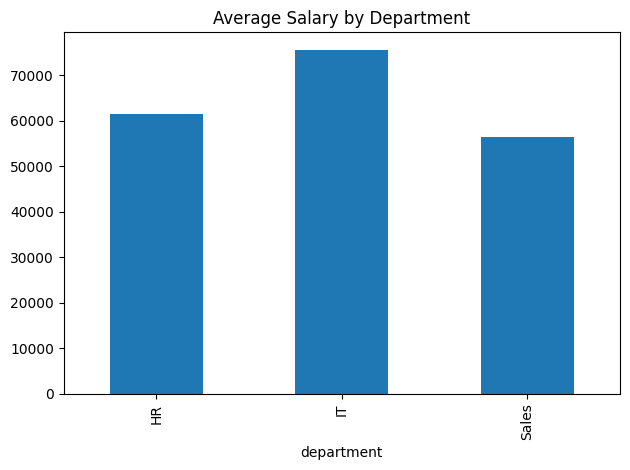

In [135]:
ax = df.groupby('department')['salary'].mean().plot.bar(title='Average Salary by Department')
plt.tight_layout()
plt.show()

### `df.plot.hist()`
**Purpose:** Histogram — see the shape of a distribution.

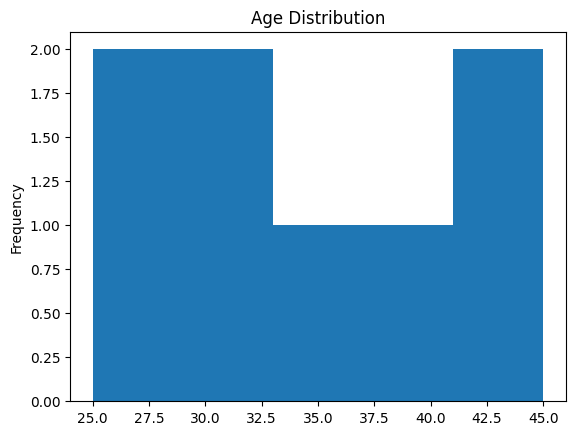

In [136]:
ax = df['age'].plot.hist(bins=5, title='Age Distribution')
plt.show()

### `df.plot.scatter()`
**Purpose:** Scatter plot — visualize the relationship between two numeric variables.

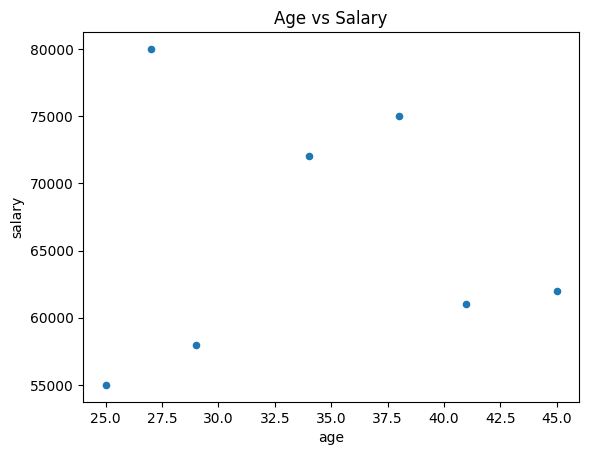

In [137]:
ax = df.plot.scatter(x='age', y='salary', title='Age vs Salary')
plt.show()

### `df.boxplot()`
**Purpose:** Box plot — visualize spread and outliers.

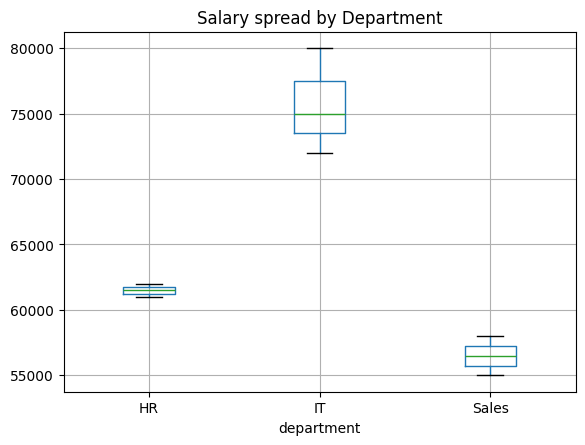

In [138]:
ax = df.boxplot(column='salary', by='department')
plt.title('Salary spread by Department')
plt.suptitle('')
plt.show()

## 17. Memory & Performance Optimization

### `df.memory_usage(deep=True)`
**Purpose:** Accurately measure memory footprint, including object/string columns.

In [139]:
df.memory_usage(deep=True)

Index          132
employee_id     64
name           431
department     417
salary          64
age             64
join_date       64
bonus_pct       64
dtype: int64

### `df.copy()`
**Purpose:** Create an independent copy — avoid accidentally mutating the original DataFrame.

In [140]:
df_copy = df.copy()
df_copy['salary'] = 0   # original df is untouched
print(df['salary'].iloc[0], df_copy['salary'].iloc[0])

55000.0 0


**Common Error with `df.copy()`**

Modifying a filtered slice without `.copy()` raises `SettingWithCopyWarning` — pandas isn't sure if you meant to change the original data.

In [141]:
try:
    sub = df[df['department'] == 'IT']
    sub['salary'] = 0   # modifying a slice without .copy()
except Exception as e:
    print(f"{type(e).__name__}: {e}")

**Fix:**

In [142]:
sub = df[df['department'] == 'IT'].copy()
sub['salary'] = 0   # safe: sub is now a fully independent DataFrame
sub[['name','salary']]

,name,salary
1,Bob,0
4,Evan,0
7,Hana,0


### `df.convert_dtypes()`
**Purpose:** Automatically convert columns to the best possible (often smaller) dtypes.

In [143]:
df.convert_dtypes().dtypes

employee_id             Int64
name                   string
department             string
salary                  Int64
age                     Int64
join_date      datetime64[us]
bonus_pct             Float64
dtype: object

## 18. Iteration (use sparingly — vectorized operations are much faster)

### `df.iterrows()`
**Purpose:** Loop through rows one at a time as (index, Series) pairs.

In [144]:
for idx, row in df.head(2).iterrows():
    print(idx, row['name'], row['salary'])

0 Alice 55000.0
1 Bob 72000.0


### `df.itertuples()`
**Purpose:** Loop through rows as lightweight named tuples — faster than `iterrows()`.

In [145]:
for row in df.head(2).itertuples():
    print(row.name, row.salary)

Alice 55000.0
Bob 72000.0


## 19. Miscellaneous Utility

### `pd.Series()`
**Purpose:** Create a 1-dimensional labeled array.

In [146]:
pd.Series([10, 20, 30], name='sample')

0    10
1    20
2    30
Name: sample, dtype: int64

### `pd.DataFrame()`
**Purpose:** Create a 2-dimensional labeled data structure.

In [147]:
pd.DataFrame({'a':[1,2], 'b':[3,4]})

,a,b
0,1,3
1,2,4


### `pd.set_option()`
**Purpose:** Change global display settings, e.g. how many rows/columns are shown.

In [148]:
pd.set_option('display.max_rows', 10)
print("max_rows now:", pd.get_option('display.max_rows'))

max_rows now: 10


### `df.style`
**Purpose:** Apply conditional formatting for a polished visual report (e.g. highlight low salaries).

In [149]:
df.head(4).style.highlight_min(subset=['salary'], color='salmon')

,employee_id,name,department,salary,age,join_date,bonus_pct
0,101,Alice,Sales,55000.000000,25,2019-03-01 00:00:00,0.050000
1,102,Bob,IT,72000.000000,34,2018-07-15 00:00:00,0.100000
2,103,Charlie,Sales,58000.000000,29,2020-01-10 00:00:00,0.070000
3,104,Diana,HR,61000.000000,41,2017-11-23 00:00:00,0.060000


## 20. Common Pandas Errors — Quick Reference

| Error | Typical Cause | Fix |
|---|---|---|
| `KeyError` | Referencing a column/index label that doesn't exist | Check `df.columns` / `df.index`, fix spelling, or use `errors='ignore'` where supported |
| `ValueError: could not convert string to float` | `.astype(float)`/`.astype(int)` on non-numeric text | Use `pd.to_numeric(col, errors='coerce')` |
| `SettingWithCopyWarning` | Modifying a filtered slice of a DataFrame directly | Add `.copy()` when you filter, then modify the copy |
| `ValueError: Index contains duplicate entries` | `.pivot()` with duplicate index/column combinations | Use `.pivot_table()` with an `aggfunc` instead |
| `MergeError` / `KeyError` on merge | Merge key column missing or misspelled in one/both DataFrames | Confirm the key exists in both frames with `set(df1.columns) & set(df2.columns)` |
| `ValueError: cannot reindex from a duplicate axis` | Duplicate index values during `reindex`/`join` | `df = df[~df.index.duplicated()]` before reindexing |
| `TypeError: unsupported operand type(s)` | Doing math on an `object`/string column | Convert with `pd.to_numeric()` or `.astype()` first |
| `FileNotFoundError` | Wrong file path in `read_csv`/`read_excel` | Verify path with `os.path.exists()`, use absolute paths |
| `ParserError` (read_csv) | Malformed CSV (extra commas, inconsistent columns) | Use `on_bad_lines='skip'` or inspect the raw file first |
| `AttributeError: Can only use .str accessor with string values` | Calling `.str.*` on a numeric column | Cast to string first: `col.astype(str).str.upper()` |
| `DateParseError` / `ValueError` in `to_datetime` | Inconsistent or invalid date formats | Use `errors='coerce'` and/or specify `format=` explicitly |

**General debugging habit:** when pandas throws an error, first print `df.dtypes` and `df.columns` —
80% of pandas errors trace back to a wrong dtype or a mistyped/missing column name.


---
### End of Notebook
This notebook covers the pandas functions used in the overwhelming majority of real-world data analysis:
loading, cleaning, filtering, aggregating, grouping, merging, time-series work, text cleaning, categorical
encoding, reshaping, correlation analysis, rolling statistics, plotting, and performance optimization —
plus the errors you're most likely to hit at each step and how to resolve them.
